In [28]:
import numpy as np
import matplotlib.pyplot as plt

In [86]:
mu_x1 = -3
mu_y1 = 0
mu_x2 = 3
mu_y2 = 0
w1 = 0.5
w2 = 1-w1
n = 500000
dt = 0.01
gamma = 1
kB = 1

x_track = []
y_track = []

def langevin_2d(Temp = 1):

    x = np.zeros(n)
    y = np.zeros(n)

    for i in range(1,n):

        p1 = np.exp((-1/2)*(((x[i-1]-mu_x1)**2)+(y[i-1]-mu_y1)**2))
        p2 = np.exp((-1/2)*(((x[i-1]-mu_x2)**2)+(y[i-1]-mu_y2)**2))

        p = w1*p1 + w2*p2

        dpdx = -(w1*(x[i-1]-mu_x1)*p1)-(w2*(x[i-1]-mu_x2)*p2)
        dpdy = -(w1*(y[i-1]-mu_y1)*p1)-(w2*(y[i-1]-mu_y2)*p2)

        grad_U_x = -dpdx/p
        grad_U_y = -dpdy/p

        mu = 1/gamma
        D = mu*kB*Temp

        x_noise = np.random.randn()
        y_noise = np.random.randn()

        x[i] = x[i-1] - mu*(grad_U_x)*dt + np.sqrt(2*D*dt)*x_noise
        y[i] = y[i-1] - mu*(grad_U_y)*dt + np.sqrt(2*D*dt)*y_noise

    return x, y



In [ ]:
results = {}

for T in [0.1, 0.5, 2, 5, 50]:
    x, y = langevin_2d(T)
    results[T] = (x, y)


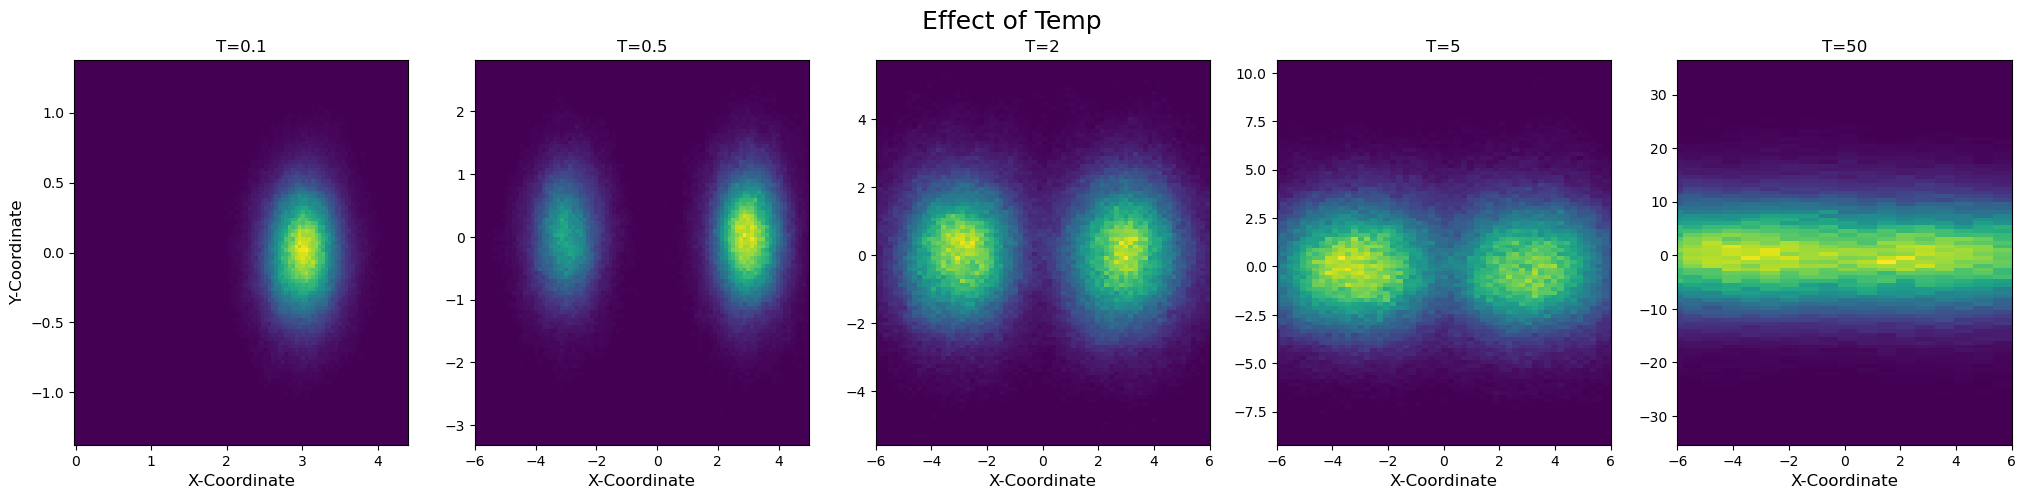

In [184]:
x1, y1 = results[0.1]
x2, y2 = results[0.5]
x3, y3 = results[2]
x4, y4 = results[5]
x5, y5 = results[50]

fig, axs = plt.subplots(1,5,figsize=(25,5))
plt.subplots_adjust(wspace=0.2)
fig.suptitle('Effect of Temp',fontsize=18)
axs[0].hist2d(x1, y1, bins =100, density=True)
axs[1].hist2d(x2, y2, bins =100, density=True)
axs[2].hist2d(x3, y3, bins =100, density=True)
axs[3].hist2d(x4, y4, bins =100, density=True)
axs[4].hist2d(x5, y5, bins =100, density=True)

axs[1].set_xlim(-6,5)
axs[2].set_xlim(-6,6)
axs[3].set_xlim(-6,6)
axs[4].set_xlim(-6,6)

axs[0].set_title('T=0.1',fontsize=12)
axs[1].set_title('T=0.5',fontsize=12)
axs[2].set_title('T=2',fontsize=12)
axs[3].set_title('T=5',fontsize=12)
axs[4].set_title('T=50',fontsize=12)

axs[0].set_ylabel("Y-Coordinate",fontsize=12)
axs[0].set_xlabel("X-Coordinate",fontsize=12)
axs[1].set_xlabel("X-Coordinate",fontsize=12)
axs[2].set_xlabel("X-Coordinate",fontsize=12)
axs[3].set_xlabel("X-Coordinate",fontsize=12)
axs[4].set_xlabel("X-Coordinate",fontsize=12);
